<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>Introduction to Xarray </h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟢 Beginner</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Time to complete: ~5 mins</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Prerequisites - OPTIONAL, delete if not required -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>🧾 Prerequisites</b><br>
Users of this notebook should have a basic understanding of:
    
* How to run a <a href="01_Jupyter_notebooks.ipynb">Jupyter notebook</a>
* How to work with <a href="07_Intro_to_numpy.ipynb">Numpy</a>

</div>

<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://knowledge.dea.ga.gov.au/guides/setup/Sandbox/sandbox/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

- <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div>

</div>

## Background
`Xarray` is a python library which simplifies working with labelled multi-dimension arrays. 
`Xarray` introduces labels in the forms of dimensions, coordinates and attributes on top of raw `numpy` arrays, allowing for more intitutive and concise development. 
More information about `xarray` data structures and functions can be found [here](http://xarray.pydata.org/en/stable/).

Once you've completed this notebook, you may be interested in advancing your `xarray` skills further, this [external notebook](https://rabernat.github.io/research_computing/xarray.html) introduces more uses of `xarray` and may help you advance your skills further. 

## Description
This notebook is designed to introduce users to `xarray` using Python code in Jupyter Notebooks.

Topics covered include:

* How to use `xarray` functions in a Jupyter Notebook cell
* How to access `xarray` dimensions and metadata
* Using indexing to explore multi-dimensional `xarray` data
* Application of built-in `xarray` functions such as sum, std and mean

***


## Setup
To run this notebook, run all the cells in the notebook starting with the "Load packages" cell. For help with running notebook cells, refer back to the [Jupyter Notebooks notebook](01_Jupyter_notebooks.ipynb). 

### Load packages
Import Python packages that are used for the analysis.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## Analysis

### Introduction to xarray
DEA uses `xarray` as its core data model. 
To better understand what it is, let's first do a simple experiment using a combination of plain `numpy` arrays and Python dictionaries.

Suppose we have a satellite image with three bands: `red`, `nir` and `swir`. 
These bands are represented as 2-dimensional `numpy` arrays and the latitude and longitude coordinates for each dimension are represented using 1-dimensional arrays. 
Finally, we also have some metadata that comes with this image.  
The code below creates fake satellite data and structures the data as a `dictionary`.

In [2]:
# Create fake satellite data
red = np.random.rand(250, 250)
nir = np.random.rand(250, 250)
swir = np.random.rand(250, 250)

# Create some lats and lons
lats = np.linspace(-23.5, -26.0, num=red.shape[0], endpoint=False)
lons = np.linspace(110.0, 112.5, num=red.shape[1], endpoint=False)

# Create metadata
title = "Image of the desert"
date = "2019-11-10"

# Stack into a dictionary
image = {
    "red": red,
    "nir": nir,
    "swir": swir,
    "latitude": lats,
    "longitude": lons,
    "title": title,
    "date": date,
}

All our data is conveniently packed in a dictionary. Now we can use this dictionary to work with the data it contains:

In [3]:
# Date of satellite image
print(image["date"])

# Mean of red values
image["red"].mean()

2019-11-10


np.float64(0.5001320396775534)

Still, to select data we have to use `numpy` indexes. 
Wouldn't it be convenient to be able to select data from the images using the coordinates of the pixels instead of their relative positions?  
This is exactly what `xarray` solves! Let's see how it works:

To explore `xarray` we have a file containing some surface reflectance data extracted from the DEA platform. 
The object that we get `ds` is a `xarray` `Dataset`, which in some ways is very similar to the dictionary that we created before, but with lots of convenient functionality available.

In [4]:
ds = xr.open_dataset("../Supplementary_data/08_Intro_to_xarray/example_netcdf.nc")
ds

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 4, y: 215, x: 251)
Coordinates:
  * time         (time) datetime64[ns] 32B 2021-06-27T23:50:11.111104 ... 202...
  * y            (y) float64 2kB -3.953e+06 -3.953e+06 ... -3.959e+06 -3.96e+06
  * x            (x) float64 2kB 1.543e+06 1.543e+06 ... 1.551e+06 1.551e+06
    spatial_ref  int32 4B ...
Data variables:
    nbart_red    (time, y, x) int16 432kB ...
    nbart_green  (time, y, x) int16 432kB ...
    nbart_blue   (time, y, x) int16 432kB ...
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

### Xarray dataset structure
A `Dataset` can be seen as a dictionary structure packing up the data, dimensions and attributes. Variables in a `Dataset` object are called `DataArrays` and they share dimensions with the higher level `Dataset`. 
The figure below provides an illustrative example:


<img src="../Supplementary_data/08_Intro_to_xarray/dataset-diagram.png" alt="drawing" width="600" align="left"/>

To access a variable we can access as if it were a Python dictionary, or using the `.` notation, which is more convenient.

In [5]:
ds["nbart_red"]

# Or alternatively:
ds.nbart_red

<xarray.DataArray 'nbart_red' (time: 4, y: 215, x: 251)> Size: 432kB
[215860 values with dtype=int16]
Coordinates:
  * time         (time) datetime64[ns] 32B 2021-06-27T23:50:11.111104 ... 202...
  * y            (y) float64 2kB -3.953e+06 -3.953e+06 ... -3.959e+06 -3.96e+06
  * x            (x) float64 2kB 1.543e+06 1.543e+06 ... 1.551e+06 1.551e+06
    spatial_ref  int32 4B ...
Attributes:
    units:         1
    nodata:        -999
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

Dimensions are also stored as numeric arrays that we can easily access:

In [6]:
ds["time"]

# Or alternatively:
ds.time

<xarray.DataArray 'time' (time: 4)> Size: 32B
array(['2021-06-27T23:50:11.111104000', '2021-07-04T23:56:22.809747000',
       '2021-07-13T23:50:12.415725000', '2021-07-20T23:56:26.354214000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 32B 2021-06-27T23:50:11.111104 ... 202...
    spatial_ref  int32 4B ...

Metadata is referred to as attributes and is internally stored under `.attrs`, but the same convenient `.` notation applies to them.

In [7]:
ds['nbart_red'].attrs["nodata"]

# Or alternatively:
ds['nbart_red'].attrs["nodata"]

np.int64(-999)

`DataArrays` store their data internally as multidimensional `numpy` arrays. 
But these arrays contain dimensions or labels that make it easier to handle the data. 
To access the underlaying numpy array of a `DataArray` we can use the `.values` notation.

In [8]:
arr = ds.nbart_red.values

type(arr), arr.shape

(numpy.ndarray, (4, 215, 251))

### Indexing

`Xarray` offers two different ways of selecting data. This includes the `isel()` approach, where data can be selected based on its index (like `numpy`).


In [9]:
print(ds.time.values)

ss = ds.nbart_red.isel(time=0)
ss

['2021-06-27T23:50:11.111104000' '2021-07-04T23:56:22.809747000'
 '2021-07-13T23:50:12.415725000' '2021-07-20T23:56:26.354214000']


<xarray.DataArray 'nbart_red' (y: 215, x: 251)> Size: 108kB
array([[ 573,  555,  510, ..., 1071,  832,  625],
       [ 623,  566,  643, ...,  897,  541,  715],
       [ 554,  530,  667, ...,  805,  792,  833],
       ...,
       [4369, 4971, 5620, ...,  598,  624,  735],
       [5353, 5354, 6145, ...,  497,  594,  546],
       [6055, 5545, 6053, ...,  434,  480,  545]],
      shape=(215, 251), dtype=int16)
Coordinates:
  * y            (y) float64 2kB -3.953e+06 -3.953e+06 ... -3.959e+06 -3.96e+06
  * x            (x) float64 2kB 1.543e+06 1.543e+06 ... 1.551e+06 1.551e+06
    time         datetime64[ns] 8B 2021-06-27T23:50:11.111104
    spatial_ref  int32 4B ...
Attributes:
    units:         1
    nodata:        -999
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

Or the `sel()` approach, used for selecting data based on its dimension of label value.

In [10]:
ss = ds.nbart_red.sel(time="2021-06-27")
ss

<xarray.DataArray 'nbart_red' (time: 1, y: 215, x: 251)> Size: 108kB
array([[[ 573,  555, ...,  832,  625],
        [ 623,  566, ...,  541,  715],
        ...,
        [5353, 5354, ...,  594,  546],
        [6055, 5545, ...,  480,  545]]], shape=(1, 215, 251), dtype=int16)
Coordinates:
  * time         (time) datetime64[ns] 8B 2021-06-27T23:50:11.111104
  * y            (y) float64 2kB -3.953e+06 -3.953e+06 ... -3.959e+06 -3.96e+06
  * x            (x) float64 2kB 1.543e+06 1.543e+06 ... 1.551e+06 1.551e+06
    spatial_ref  int32 4B ...
Attributes:
    units:         1
    nodata:        -999
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

Slicing data is also used to select a subset of data.

In [11]:
ss.x.values[100]

np.float64(1546065.0)

In [12]:
ss = ds.nbart_red.sel(time="2021-06-27", x=slice(2378390, 2380390))
ss

<xarray.DataArray 'nbart_red' (time: 1, y: 215, x: 0)> Size: 0B
array([], shape=(1, 215, 0), dtype=int16)
Coordinates:
  * time         (time) datetime64[ns] 8B 2021-06-27T23:50:11.111104
  * y            (y) float64 2kB -3.953e+06 -3.953e+06 ... -3.959e+06 -3.96e+06
  * x            (x) float64 0B 
    spatial_ref  int32 4B ...
Attributes:
    units:         1
    nodata:        -999
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

Xarray exposes lots of functions to easily transform and analyse `Datasets` and `DataArrays`. 
For example, to calculate the spatial mean, standard deviation or sum of the green band:

In [13]:
print("Mean of RED band:", ds.nbart_red.mean().values)
print("Standard deviation of red band:", ds.nbart_red.std().values)
print("Sum of red band:", ds.nbart_red.sum().values)

Mean of RED band: 913.7066153988696
Standard deviation of red band: 697.3316721169547
Sum of red band: 197232710


### Plotting data with Matplotlib
Plotting is also conveniently integrated in the library.

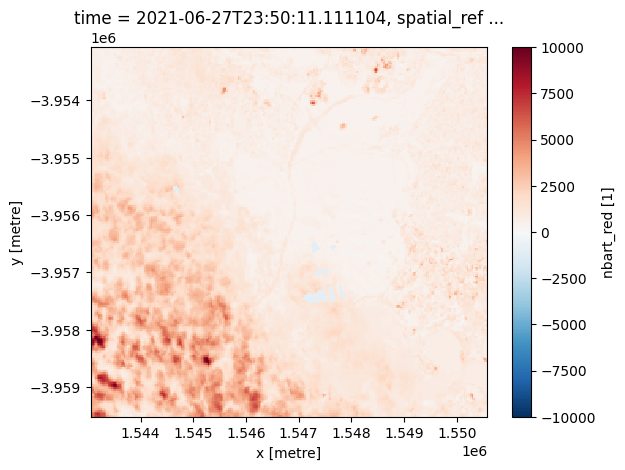

In [14]:
ds["nbart_red"].isel(time=0).plot();

...but we still can do things manually using `numpy` and `matplotlib` if you choose:

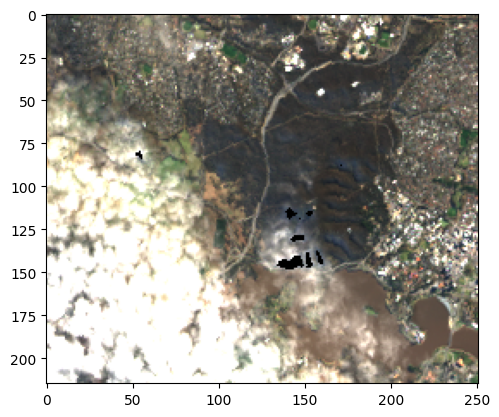

In [15]:
rgb = np.dstack((ds.nbart_red.isel(time=0).values,
                 ds.nbart_green.isel(time=0).values,
                 ds.nbart_blue.isel(time=0).values))
rgb = np.clip(rgb, 0, 2000) / 2000

plt.imshow(rgb);

But compare the above to elegantly chaining operations within `xarray`:

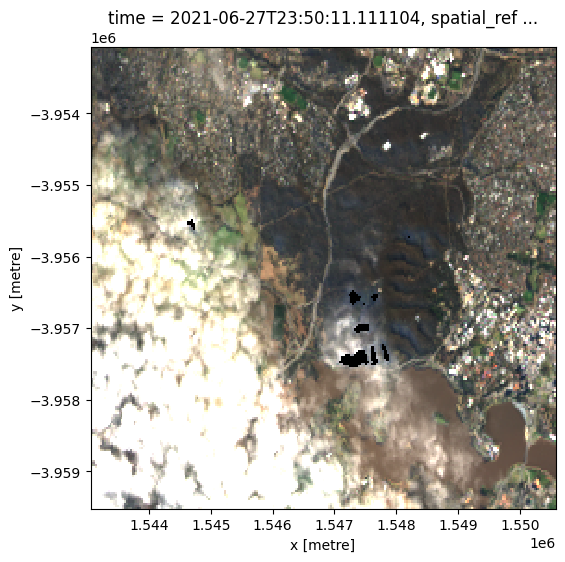

In [16]:
ds[["nbart_red", "nbart_green", "nbart_blue"]].isel(time=0).to_array().plot.imshow(vmin=0, vmax=2000, figsize=(6, 6));

## Recommended next steps

For more advanced information about working with Jupyter Notebooks or JupyterLab, you can explore [JupyterLab documentation page](https://jupyterlab.readthedocs.io/en/stable/user/notebook.html).

To continue working through the notebooks in this beginner's guide, the following notebooks are designed to be worked through in the following order:

1. [Jupyter Notebooks](01_Jupyter_notebooks.ipynb)
2. [Digital Earth Australia](02_DEA.ipynb)
3. [Products and Measurements](03_Products_and_measurements.ipynb)
4. [Loading data](04a_Loading_data_STAC.ipynb)
5. [Plotting](05_Plotting.ipynb)
6. [Performing a basic analysis](06_Basic_analysis.ipynb)
7. [Introduction to Numpy](07_Intro_to_numpy.ipynb)
8. **Introduction to Xarray (this notebook)**
9. [Parallel processing with Dask](09_Parallel_processing_with_Dask.ipynb)

Once you have you have completed the above nine tutorials, join advanced users in exploring:

* The "Datasets" directory in the repository, where you can explore DEA products in depth.
* The "How_to_guides" directory, which contains a recipe book of common techniques and methods for analysing DEA data.
* The "Real_world_examples" directory, which provides more complex workflows and analysis case studies.

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last tested:**


In [17]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-12-10'